# Building Makemore Part 3: Activations & Gradients, BatchNorm

Exercises:

- <span style = "color:green;"> E01: I did not get around to seeing what happens when you initialize all weights and biases to zero. Try this and train the neural net. You might think either that 1) the network trains just fine or 2) the network doesn't train at all, but actually it is 3) the network trains but only partially, and achieves a pretty bad final performance. Inspect the gradients and activations to figure out what is happening and why the network is only partially training, and what part is being trained exactly. </span>

- <span style = "color:green;"> E02: BatchNorm, unlike other normalization layers like LayerNorm/GroupNorm etc. has the big advantage that after training, the batchnorm gamma/beta can be "folded into" the weights of the preceeding Linear layers, effectively erasing the need to forward it at test time. Set up a small 3-layer MLP with batchnorms, train the network, then "fold" the batchnorm gamma/beta into the preceeding Linear layer's W,b by creating a new W2, b2 and erasing the batch norm. Verify that this gives the same forward pass during inference. i.e. we see that the batchnorm is there just for stabilizing the training, and can be thrown out after training is done! pretty cool. </span>


### Experiment with weights and biases initialised to zero.

We will import and reuse the standard building blocks we have created so far:

- importing packages
- importing words and create the mapping from characters to integers
- building the dataset, i.e., training, dev/val, test


In [24]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [25]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [26]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [27]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


Next we will initialise the weights and biases - to zero for the experiment. Now this step is where the balancing act appears when you are not applying some normalisation techniques like batchnorm.

In [28]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g) * 0.0
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) * 0.0
b1 = torch.randn(n_hidden,                        generator=g) * 0.0
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.0
b2 = torch.randn(vocab_size,                      generator=g) * 0.0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


Now we train - I have removed the batchnorm layer.


In [29]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
#   # BatchNorm layer
#   # -------------------------------------------------------------
#   bnmeani = hpreact.mean(0, keepdim=True)
#   bnstdi = hpreact.std(0, keepdim=True)
#   hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
#   with torch.no_grad():
#     bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
#     bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
#   # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.2958
  10000/ 200000: 2.6793
  20000/ 200000: 2.8210
  30000/ 200000: 3.0941
  40000/ 200000: 3.0673
  50000/ 200000: 3.0884
  60000/ 200000: 2.8090
  70000/ 200000: 2.6637


KeyboardInterrupt: 

Now to investigate the effects

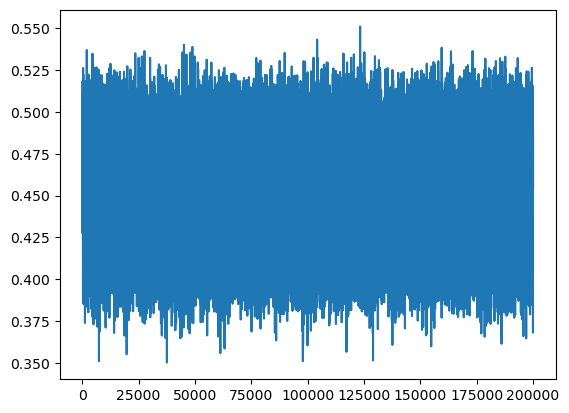

In [ ]:
plt.plot(lossi)

In [ ]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1  + b1
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
#   hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.8226585388183594
val 2.8209712505340576


So no overfitting found, and quite bad values of the loss function compared to other techniques. LEts now look at the activations and gradient distribution.

h: mean +0.00, std 0.00, saturated: 0.00%


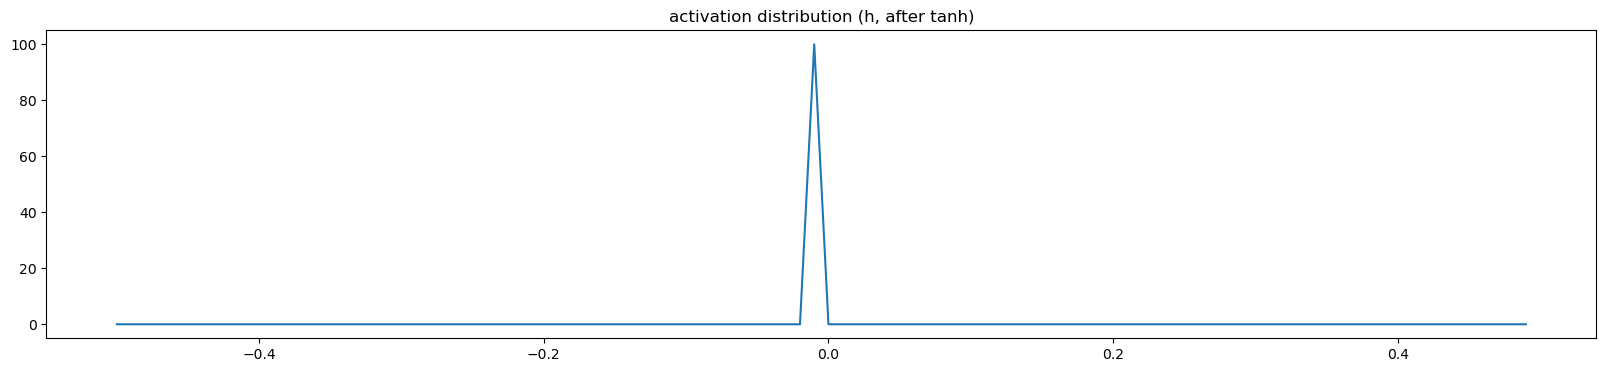

In [ ]:
# after training, run one forward pass to capture activations
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)

plt.figure(figsize=(20, 4))
hy, hx = torch.histogram(h, density=True)
plt.plot(hx[:-1].detach(), hy.detach())
plt.title('activation distribution (h, after tanh)')
print('h: mean %+.2f, std %.2f, saturated: %.2f%%' % (h.mean(), h.std(), (h.abs() > 0.97).float().mean()*100))

h.grad: mean +0.000000e+00, std 0.000000e+00


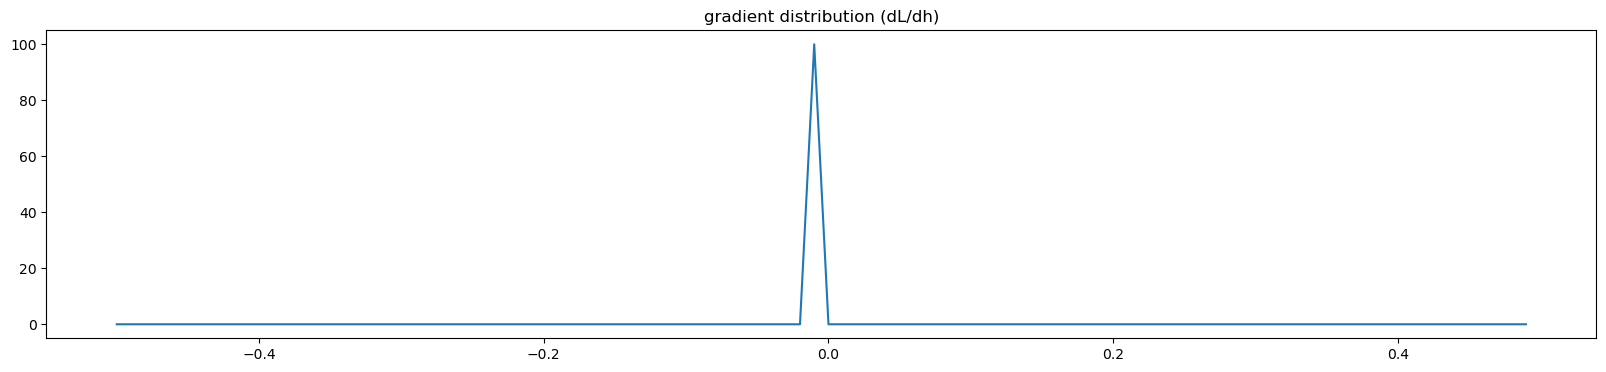

In [ ]:
# fresh forward pass so we have a clean graph to inspect
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
h.retain_grad()
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yb)

for p in parameters: p.grad = None
loss.backward()

plt.figure(figsize=(20, 4))
hy, hx = torch.histogram(h.grad, density=True)
plt.plot(hx[:-1].detach(), hy.detach())
plt.title('gradient distribution (dL/dh)')
print('h.grad: mean %+e, std %e' % (h.grad.mean(), h.grad.std()))

    C | shape             (27, 10) | grad mean +0.000000 | grad std 0.000000e+00
   W1 | shape            (30, 200) | grad mean +0.000000 | grad std 0.000000e+00
   b1 | shape               (200,) | grad mean +0.000000 | grad std 0.000000e+00
   W2 | shape            (200, 27) | grad mean +0.000000 | grad std 0.000000e+00
   b2 | shape                (27,) | grad mean -0.000000 | grad std 3.763609e-02


Text(0.5, 1.0, 'weight gradient distribution')

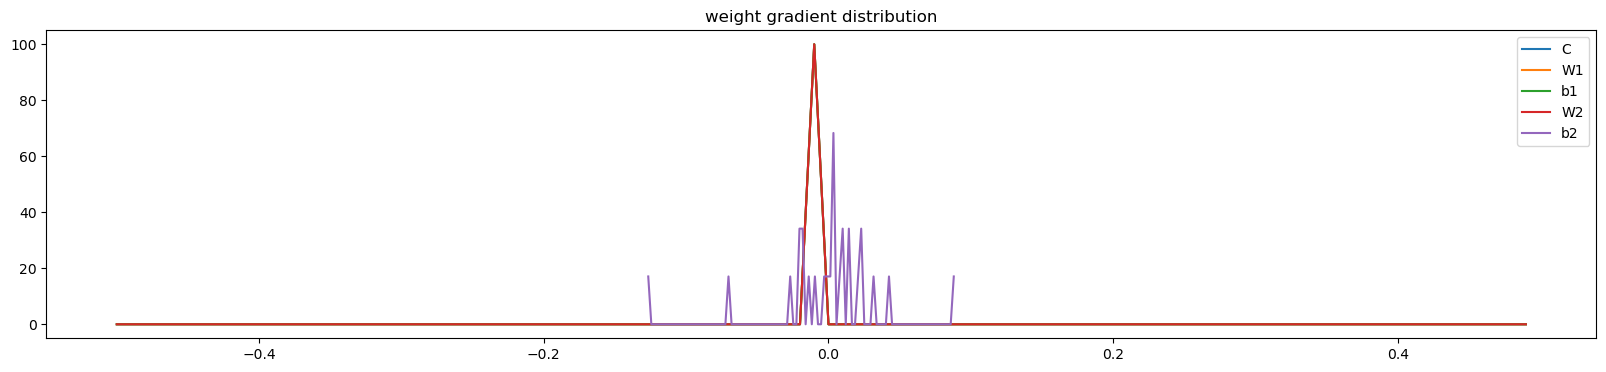

In [ ]:
plt.figure(figsize=(20, 4))
legends = []
for name, p in zip(['C','W1','b1','W2','b2'], parameters):
    if p.grad is not None:
        print('%5s | shape %20s | grad mean %+f | grad std %e' % (name, tuple(p.shape), p.grad.mean(), p.grad.std()))
        hy, hx = torch.histogram(p.grad, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(name)
plt.legend(legends)
plt.title('weight gradient distribution')

In [ ]:
counts = torch.zeros(vocab_size)
for ix in Ytr:
    counts[ix] += 1
empirical_logprobs = torch.log(counts / counts.sum())

print('b2 (trained):        ', b2.detach())
print('empirical log-probs: ', empirical_logprobs)

b2 (trained):         tensor([ 1.9370,  1.9962, -0.5748, -0.2951,  0.1810,  1.4917, -1.6479, -0.9013,
         0.5050,  1.3279, -0.4530,  0.0915,  1.0984,  0.3514,  1.3779,  0.5578,
        -1.5077, -2.8361,  0.9914,  0.5634,  0.1826, -0.4124, -0.6069, -1.5859,
        -1.9036,  0.7546, -0.6857])
empirical log-probs:  tensor([-1.9638, -1.9064, -4.4655, -4.1775, -3.7181, -2.4141, -5.5318, -4.7698,
        -3.3942, -2.5552, -4.3732, -3.8080, -2.7919, -3.5462, -2.5244, -3.3532,
        -5.4022, -6.7399, -2.8850, -3.3465, -3.7175, -4.2895, -4.5043, -5.4662,
        -5.7908, -3.1454, -4.5442])


### E01: Summary

When everything is zero-initialized, W1=0, b1=0 forces hpreact=0 and thus h=tanh(0)=0 for every input — the hidden layer is dead in the forward pass, independent of any gradient. Separately, W2=0 blocks all gradient from flowing backward past it (dL/dh = dlogits @ W2.T = 0), so W1, b1, and C never receive a gradient either. W2 itself is also stuck, since its own gradient (h.T @ dlogits) is zero because h=0. Only b2 escapes — its gradient (dlogits.sum(0)) doesn't route through h or W2 at all, so it trains freely and ends up fitting the unigram character distribution, which is the only thing the network is capable of representing once every other parameter is frozen.

## Folding in Batchnorm parameters (gamma, beta)

E02: BatchNorm, unlike other normalization layers like LayerNorm/GroupNorm etc. has the big advantage that after training, the batchnorm gamma/beta can be "folded into" the weights of the preceeding Linear layers, effectively erasing the need to forward it at test time. Set up a small 3-layer MLP with batchnorms, train the network, then "fold" the batchnorm gamma/beta into the preceeding Linear layer's W,b by creating a new W2, b2 and erasing the batch norm. Verify that this gives the same forward pass during inference. i.e. we see that the batchnorm is there just for stabilizing the training, and can be thrown out after training is done! pretty cool.

I have adapted the code for the Collab notebook slightly so that we have a 3-layer MLP with batchnorms on every linear layer, except the final layer.


In [31]:
# Let's train a small 3-layer MLP with BatchNorm in the hidden layers
# The classes we create here are the same API as nn.Module in PyTorch

class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd),            generator=g)
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False),
]

with torch.no_grad():
  # last layer: make less confident
#   layers[-1].gamma *= 0.1
  layers[-1].weight *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

16370


Now training

In [32]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function

  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.3037


Now i think we perform two different forward passes: One with batchnorm and one without- but with W2 and b2, to verify they are the same.

In [34]:
#Regular BatchNorm Forward Pass compared to Folded Forward Pass with BatchNorm layers folded into Linear layers

#This is so we don't continue to update the running mean and variance of the BatchNorm layers during evaluation
for layer in layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

folded_layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False),
]

# indices in `layers`: [Linear0, BN0, Tanh0, Linear1, BN1, Tanh1, Linear2]
# indices in `folded_layers`: [Linear0, Tanh0, Linear1, Tanh1, Linear2]
# (layers Linear idx, layers BatchNorm idx, folded_layers Linear idx)
pairs = [(0, 1, 0), (3, 4, 2)]
for lin_idx, bn_idx, folded_idx in pairs:
    lin = layers[lin_idx]
    bn = layers[bn_idx]
    std = torch.sqrt(bn.running_var + bn.eps)
    folded_layers[folded_idx].weight = lin.weight * (bn.gamma / std)
    folded_layers[folded_idx].bias = (bn.beta - bn.gamma * bn.running_mean / std).view(-1)

folded_layers[-1].weight = layers[-1].weight



#Forward pass on dev set
x = Xdev 
emb = C[x]
x1 = emb.view(emb.shape[0], -1)
for layer in layers:
    x1 = layer(x1)

x2 = emb.view(emb.shape[0], -1)
for layer in folded_layers:
    x2 = layer(x2)

print((x1 - x2).abs().max())
print(torch.allclose(x1, x2, atol=1e-5))

tensor(1.9073e-06, grad_fn=<MaxBackward1>)
True


Therefore, one can include the effects of BatchNorm parameters gamma and beta into the linear layers for the final forward pass as we see here that they are equivalent.